# Native Sparse Attention（NSA）：压缩 + 选块 + 滑窗三分支

> DeepSeek 的"原生稀疏注意力"。用廉价的**块压缩**粗看全局、并顺手产出选块路由，再用 **top-k 选块**
> 在重要的少数块里恢复细节，加一条**滑窗**兜底局部 —— 三分支由一个从 query 算出的**门控**加权合并。

本章有**两个版本**，本 notebook 各讲一半：
- `nsa.py` —— 自写纯 PyTorch、三分支 mask 版，把**机制**讲透（§1–§4）。
- `nsa_triton.py` —— 完整提取 lucidrains 的 **1987 行真实稀疏 triton kernel**，逐段拆解它怎么把
  这套设计落到**硬件**（§5）。

In [1]:
import sys, math
from pathlib import Path

import torch
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

ROOT = Path.cwd()
while not (ROOT / "common").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(ROOT / "08-native-sparse-attention"))

from nsa import NativeSparseAttention

torch.manual_seed(0)
print("跑在", torch.cuda.get_device_name(0))

# 中文正常显示 + 暗色代码高亮（适配深色编辑器），见 common/nbtools.py
from common.nbtools import setup_cjk, show_code
setup_cjk()


跑在 NVIDIA GeForce RTX 4090


'Noto Sans SC'

## 1. 稀疏的"鸡生蛋"难题，与 NSA 的破局

稀疏的目标是把 full attention 的 $O(S^2)$ 降下来 —— **只算重要的那些 KV**。但马上撞墙：

> 要判断 query 和某个 KV 重不重要，得先算它俩的注意力分数；要判断**所有** KV，就是 full
> attention，$O(S^2)$ 原地复活。**选择的前提是打分，而打分的代价 ≈ 不稀疏。**

NSA 用**两级筛**破局：

1. **块压缩（compressed）= 廉价粗筛 + 免费路由器**：KV 按块压成压缩 token（$S\to S/b$），query
   attend 这 $S/b$ 个，便宜 $b$ 倍。**关键副产品**：query 对每个压缩块的分数 = 块的重要性 —— 顺手
   就出来，不额外花钱。
2. **top-k 选块（selected）= 精筛恢复细节**：拿上一步的块分数，每个 query 选 top-k 个块，只对这些块的
   **原始** token 做精细 attention。把压缩丢掉的细节，只在重要的少数块补回来。
3. **滑窗（sliding）= 保底局部**：固定 attend 最近窗口，最近的 token 几乎总相关，不值得"选"。

In [2]:
dim, H, hd, S = 256, 4, 64, 512
bs, topk, win = 64, 4, 128
model = NativeSparseAttention(dim, n_heads=H, head_dim=hd, block_size=bs,
                              num_selected_blocks=topk, sliding_window_size=win).cuda()
x = torch.randn(2, S, dim, device="cuda")
out, br = model(x, return_branches=True)

nbk = S // bs
print(f"输出: {tuple(out.shape)}")
print(f"压缩: {S} token → {nbk} 个压缩块（降 {bs}×）—— compressed 分支只 attend 这 {nbk} 个")
print("三分支输出: " + ", ".join(f"{k}={tuple(v.shape)}" for k, v in br.items() if k != "gates"))
print(f"门控 gates: {tuple(br['gates'].shape)}  (每个 head、每个 token 的三分支权重，softmax 归一)")

输出: (2, 512, 256)
压缩: 512 token → 8 个压缩块（降 64×）—— compressed 分支只 attend 这 8 个
三分支输出: compressed=(2, 4, 512, 64), selected=(2, 4, 512, 64), sliding=(2, 4, 512, 64)
门控 gates: (2, 4, 512, 3)  (每个 head、每个 token 的三分支权重，softmax 归一)


## 2. 三分支各看一部分上下文，门控融合

NSA 把稀疏注意力拆成**三条并行分支**，各看一部分上下文，最后用门控融合。记块大小 $B$、压缩块数 $n_b=S/B$：

**① compressed（压缩）**：每个 KV 块 mean-pool 成一个压缩 token $\bar k_b=\frac1B\sum_{j\in b}k_j$（$\bar v_b$ 同），query 去 attend **全部** $n_b$ 个压缩 token：

$$o^{\text{cmp}}_i=\sum_{b:\,\text{块}b\,\le\, i}\operatorname{softmax}_b\!\Big(\tfrac{q_i^\top\bar k_b}{\sqrt d}\Big)\,\bar v_b.$$

粗粒度全局视野，只算 $n_b$ 个 key。**顺带**：这里的分数 $q_i^\top\bar k_b$ 直接拿给分支 ② 选块。

**② selected（选择）**：用 ① 的压缩分数为每个 query 选 top-$k$ 个原始块 $\mathcal S(i)=\operatorname{top\text{-}k}_b\,(q_i^\top\bar k_b)$，只 attend 选中块的原始 token：

$$o^{\text{sel}}_i=\operatorname{Attn}\big(q_i,\,\{(k_j,v_j): j\in\mathcal S(i)\}\big).$$

细粒度补回重点细节（这就是第 07 章的块稀疏，只是选块依据来自压缩分支）。

**③ sliding window（滑窗）**：attend 最近 $w$ 个 token，$o^{\text{win}}_i=\operatorname{Attn}(q_i,\{(k_j,v_j): i-w<j\le i\})$，保证局部性（第 04 章的滑窗）。

**门控融合**：从 query 算出三个权重 $g_i=\operatorname{softmax}(W_g x_i)\in\mathbb R^3$，加权合并：

$$o_i=g^{\text{cmp}}_i\,o^{\text{cmp}}_i+g^{\text{sel}}_i\,o^{\text{sel}}_i+g^{\text{win}}_i\,o^{\text{win}}_i.$$

下面对一个具体 query（$i=400$）画出三分支各自**能看到的 key 范围**，再看门控如何在三分支间分配权重。

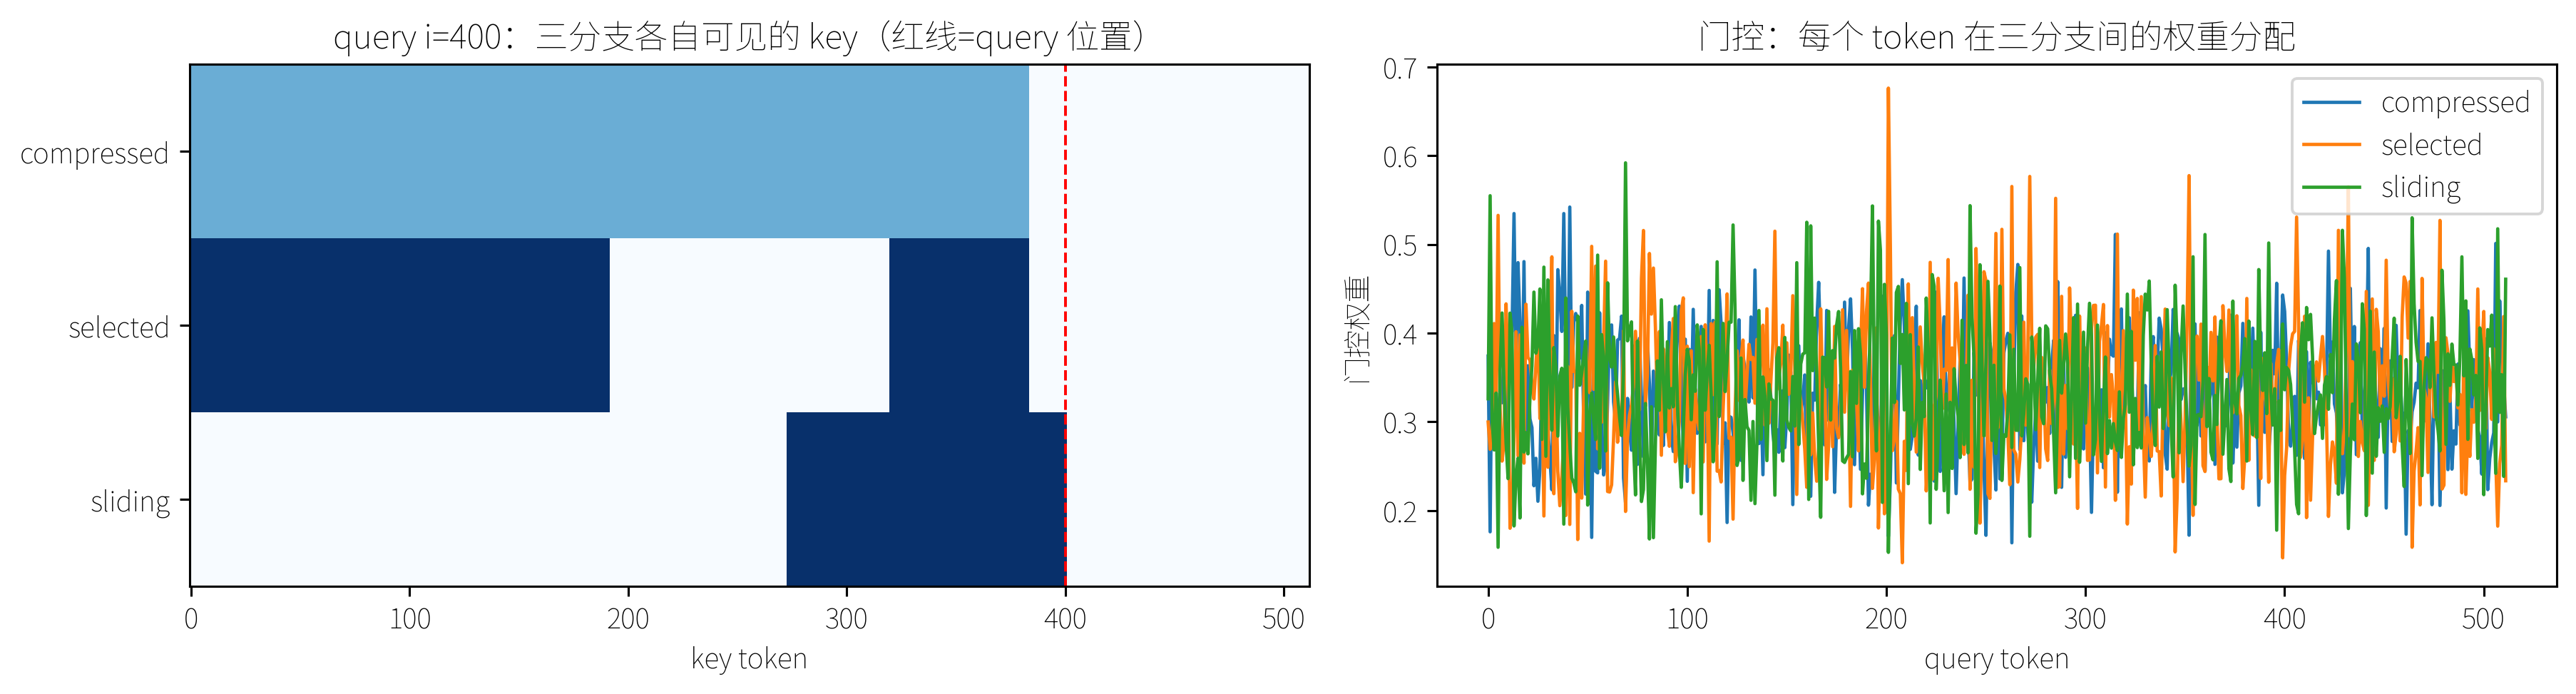

compressed 看全局（粗，覆盖整块）、selected 补重点细节、sliding 保最近局部；门控决定信谁。


In [3]:
# 取出 q/k/v，复算压缩分数（供本节与 §3 用）
qkv = model.to_qkv(x).view(2, S, 3, H, hd).permute(2, 0, 3, 1, 4)  # (3,B,H,S,D)
q_, k_, v_ = qkv[0], qkv[1], qkv[2]
out_cmp, blk_sim = model.compressed_branch(q_, k_, v_)             # blk_sim: (B,H,S,nbk)

i = 400
vis = np.zeros((3, S))
# compressed：可见所有"整块都 <= i"的压缩块（覆盖其原始 token 范围）
for b in range(nbk):
    if b * bs + bs - 1 <= i:
        vis[0, b * bs:(b + 1) * bs] = 0.5
# selected：query i 选的 top-k 块
sel = blk_sim[0, 0, i].topk(min(topk, nbk)).indices.cpu().numpy()
for b in sel:
    vis[1, b * bs:(b + 1) * bs] = 1.0
# sliding：最近 win 个
vis[2, max(0, i - win + 1):i + 1] = 1.0

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
axes[0].imshow(vis, aspect="auto", cmap="Blues", interpolation="nearest")
axes[0].set_yticks([0, 1, 2]); axes[0].set_yticklabels(["compressed", "selected", "sliding"])
axes[0].axvline(i, color="r", ls="--", lw=1); axes[0].set_xlabel("key token")
axes[0].set_title(f"query i={i}：三分支各自可见的 key（红线=query 位置）")

gates = br["gates"][0].mean(0).detach().cpu().numpy()  # (S,3) 平均 over heads
for j, name in enumerate(["compressed", "selected", "sliding"]):
    axes[1].plot(gates[:, j], label=name, lw=1.2)
axes[1].legend(); axes[1].set_xlabel("query token"); axes[1].set_ylabel("门控权重")
axes[1].set_title("门控：每个 token 在三分支间的权重分配")
plt.tight_layout(); plt.show()
print("compressed 看全局（粗，覆盖整块）、selected 补重点细节、sliding 保最近局部；门控决定信谁。")

## 3. 选块路由：压缩分数顺手选块（压缩 ↔ 选择的联动）

NSA 最妙的一步：**选块的依据不是单独算的，而是压缩分支顺手产出的**。下面画出 `blk_sim`
（query × 压缩块 的分数矩阵）—— 它既是 compressed 分支的注意力分布，又是 selected 分支的选块依据。

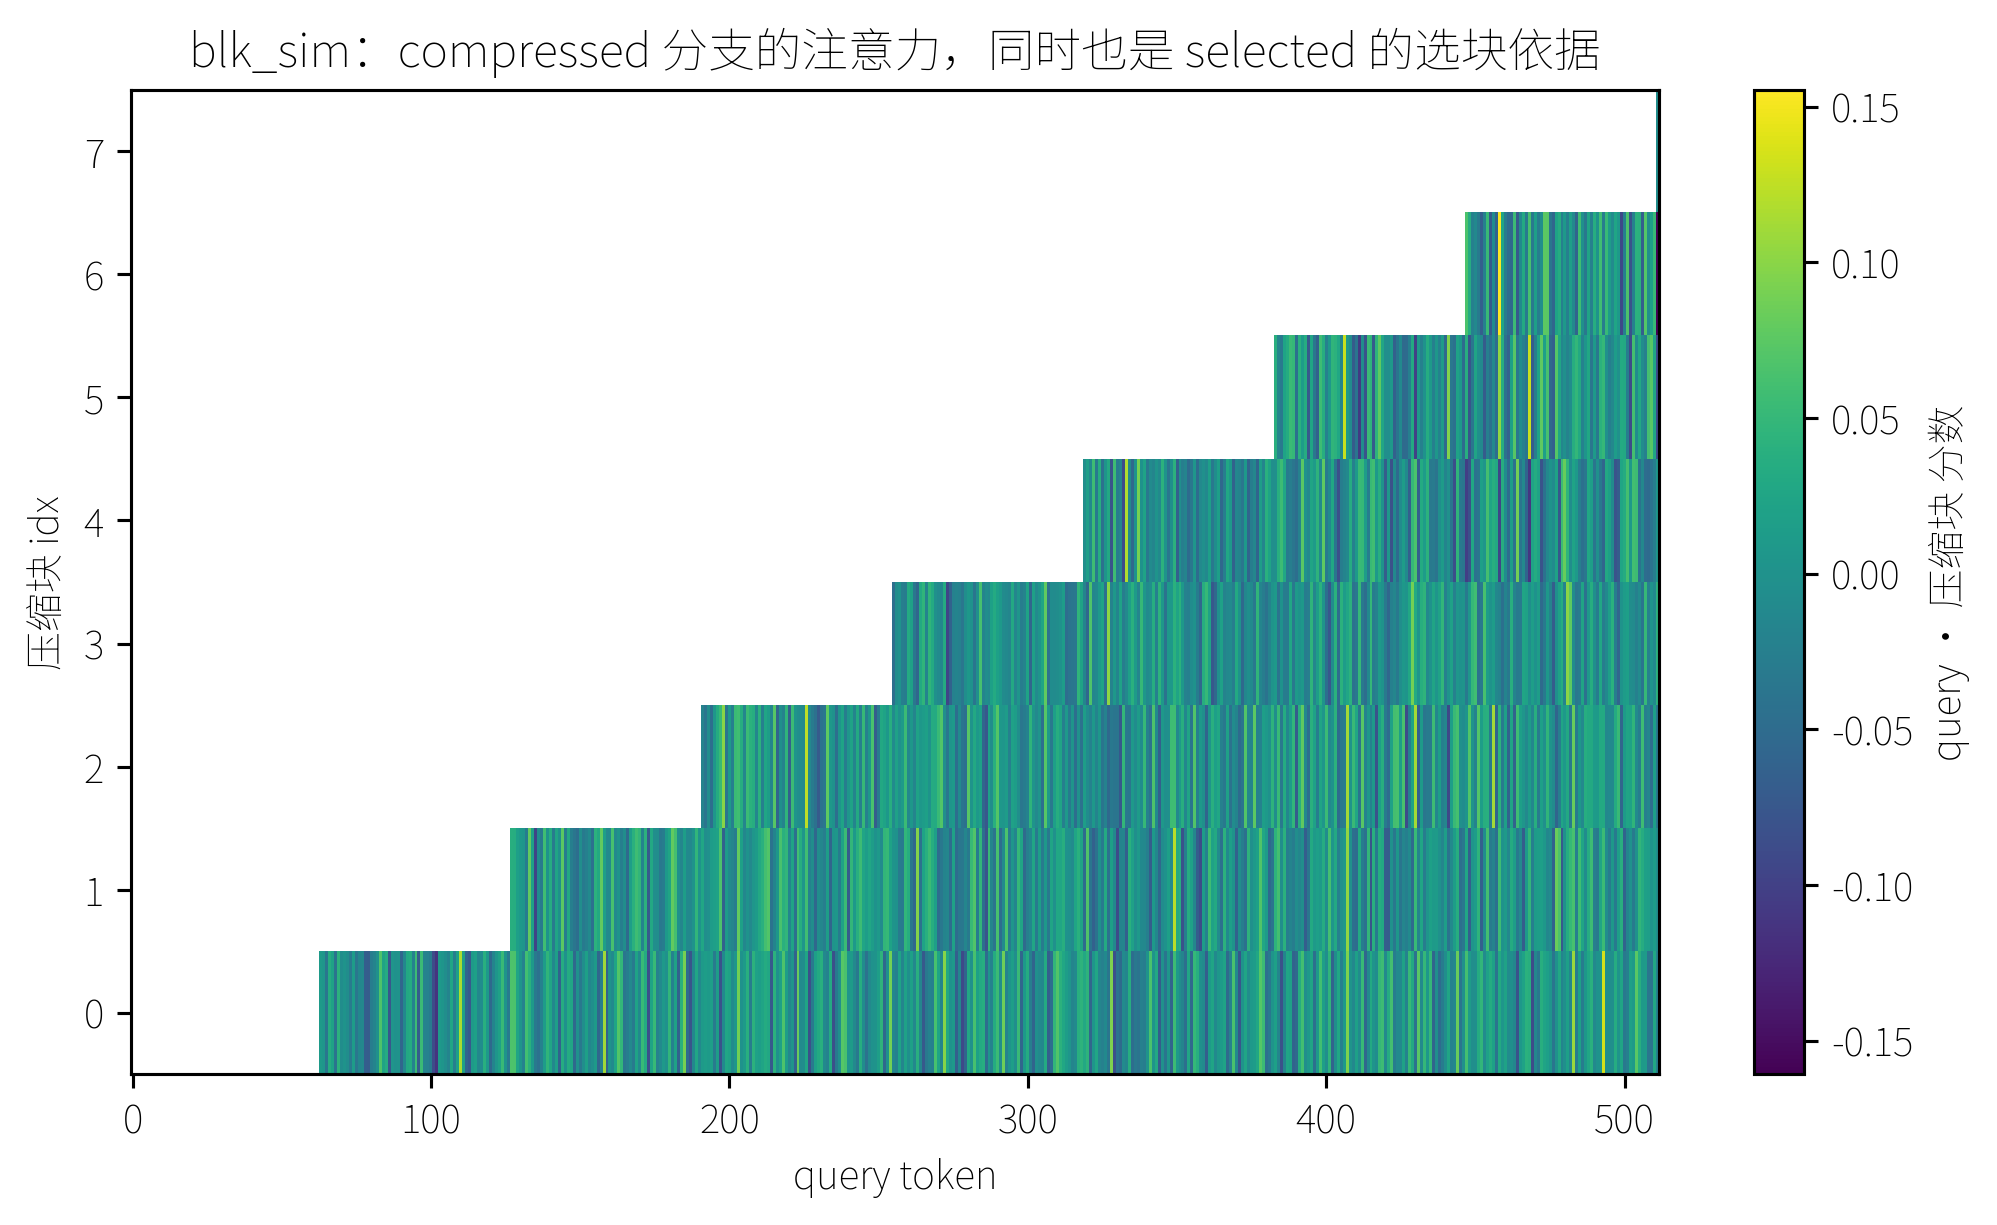

每个 query（列）取分数最高的 top-4 个块（行）= 它选中的块。
→ 压缩分支算这张表，选择分支直接白嫖，省掉了'为选块单独打分'的开销。


In [4]:
sim = blk_sim[0, 0].detach().float().cpu().clone()   # (S, nbk)
sim[sim == float("-inf")] = float("nan")             # causal 屏蔽位置画成空白

plt.figure(figsize=(7.5, 4.5))
plt.imshow(sim.T, aspect="auto", cmap="viridis", origin="lower", interpolation="nearest")
plt.colorbar(label="query · 压缩块 分数")
plt.xlabel("query token"); plt.ylabel("压缩块 idx")
plt.title("blk_sim：compressed 分支的注意力，同时也是 selected 的选块依据")
plt.tight_layout(); plt.show()
print(f"每个 query（列）取分数最高的 top-{topk} 个块（行）= 它选中的块。")
print("→ 压缩分支算这张表，选择分支直接白嫖，省掉了'为选块单独打分'的开销。")

## 4. 为什么按"块"选 → 硬件对齐（引出 kernel）

NSA 标题里的 **Hardware-Aligned** 就在这里：选"块"而非单 token，gather 的是**连续内存段**，GPU 上
连续访存、能套 FlashAttention 式的分块在线 softmax。若按单 token 选，gather 离散、访存碎片化，反而慢。

简要版 `nsa.py` 用 mask 实现选块（算了全部分数再 mask，**不省算，只为讲清机制**）。真正省算、省访存，
要靠下面的 triton kernel：**只 gather 选中的块、只算它们**。

## 5. 真实 NSA triton kernel（1987 行）—— `nsa_triton.py`

本仓库**完整提取**了 lucidrains 的 NSA 稀疏 kernel（来源/改动见 `SOURCES.md`）。它实现的是三分支里
**计算最重**的一段：给定每个 query 选中的块索引 `selected_block_indices`，只对这些块（+ 滑窗）做
flash 式在线 softmax；而"块压缩、算块分数、top-k 选块、门控合并"是 host 端 PyTorch 逻辑。

入口：`native_sparse_attend(fq, fk, fv, block_size, selected_block_indices, fmask, ...)`。下面显示完整源码。

In [5]:
from IPython.display import Code
# 完整显示提取来的 kernel 源码（带语法高亮）；逐段讲解见下方
show_code(str(ROOT / "08-native-sparse-attention" / "nsa_triton.py"))

### 逐段读懂 forward kernel

**① grid 切分：GQA 一次加载一组 query head（`native_sparse_attn_forward`）**

```python
grid = lambda META: (triton.cdiv(seqlen_q, META["BLOCK"]),  # query 分块（每块 16）
                     batch * kv_heads,                       # ← 注意是 kv_heads！
                     (2 if return_sliding_window_out else 1))
```
第二维用 **kv_heads**：一个 program 负责一个 KV head，把同组的 query head **一次性加载**，KV 只从显存
读一次、被组内多个 query head 复用 —— GQA 的省带宽收益在 kernel 层兑现。

**② Part 1 — 对角块 + 滑窗（连续访问的 "local"）**

当前 query 块自己所在的对角块（块内 causal）+（`SLIDING` 时）相邻前一块，key 位置连续，标准 flash 累加。

**③ Part 2 — per-query 选块 gather（"sparse" 的灵魂）**

```python
blocks_offs_n = block_indices[:, None] * (BLOCK * NUM_BLOCKS_PER_SEL) \
              + tl.arange(0, BLOCK)[None, :] + (off_blocks_per_sel * BLOCK)
k_block = tl.load(block_k_ptrs, mask=blocks_offs_n[:, :, None] < seqlen_k, other=0.)
```
把"每个 query 选的块号"翻译成原始序列里的实际 key 位置，直接 gather —— 不是固定稀疏模式，是
**query-dependent 的动态选块**。

**④ GQA 凑 16 维**

`tl.dot` 要求 M 维 ≥ 16，而一组 query head 数常 < 16。于是广播复制 `QUERY_EXPAND_DIM = 16 //
QUERY_HEAD_GROUPS` 次凑满 16 做矩阵乘，算完再 `tl.reduce(reduce_avg)` 还原。

**⑤ local 与 sparse 汇入同一个在线 softmax**

Part 1 / Part 2 共享一套滚动统计量 `m_i / lse_i / acc_o`，两段贡献被正确合并归一；sliding 与 selected
由 grid 第三维分成两个 program、各自输出 lse，host 层再门控合并。

### 逐段读懂 backward kernel

反向的难点恰恰来自 Part 2 的动态 gather：**多个不同的 query 可能选中同一个 KV 块**，该块的 `dk/dv`
会收到多个 query 的梯度贡献，必须**累加**而非覆盖。kernel 的处理：

- `dq/dk/dv` 用 **fp32 零初始化**，再用 `tl.atomic_add(..., sem='relaxed')` 累加；
- `backward_preprocess_do_o_dot` 先算 `delta = rowsum(do ∘ o)` —— flash 反向标准预处理；
- 反向也分 sparse / causal 两段，与前向的 Part 2 / Part 1 对称。

In [6]:
# 验证：把库的 triton 入口替换为我们的拷贝，跑完整 NSA，对齐库的 PyTorch 路径（fwd+bwd）
import native_sparse_attention_pytorch.triton_native_sparse_attention as lib_t
from native_sparse_attention_pytorch import SparseAttention
from nsa_triton import native_sparse_attend

lib_t.native_sparse_attend = native_sparse_attend  # 注入本仓库拷贝的 kernel

def build(use_triton, seed=0):
    torch.manual_seed(seed)
    return SparseAttention(
        dim=256, dim_head=64, heads=4, sliding_window_size=64,
        compress_block_size=32, compress_block_sliding_stride=32,
        selection_block_size=32, num_selected_blocks=4,
        causal=True, use_triton_kernel=use_triton).cuda().eval()

xt = torch.randn(2, 512, 256, device="cuda")
mt = build(True); mr = build(False); mr.load_state_dict(mt.state_dict())
x1 = xt.clone().requires_grad_(True); x2 = xt.clone().requires_grad_(True)
o1, o2 = mt(x1), mr(x2)
print("前向 max diff（triton 拷贝 vs 库 PyTorch 路径）:", (o1 - o2).abs().max().item())
o1.sum().backward(); o2.sum().backward()
print("反向 max diff:", (x1.grad - x2.grad).abs().max().item())
print("→ 本仓库拷贝的 1987 行 kernel，在真实 NSA pipeline 里 fwd+bwd 都对齐 PyTorch 参考。")

前向 max diff（triton 拷贝 vs 库 PyTorch 路径）: 2.92360782623291e-05
反向 max diff: 0.00016933679580688477
→ 本仓库拷贝的 1987 行 kernel，在真实 NSA pipeline 里 fwd+bwd 都对齐 PyTorch 参考。


## 6. 收尾

- **简要版 `nsa.py`** 讲清"为什么"：压缩=粗筛+免费路由、选块=精筛恢复细节、滑窗=兜底局部，门控融合。
- **深度优化版 `nsa_triton.py`** 讲清"怎么快"：per-query 动态 gather、GQA 凑 16、local+sparse 汇入同一
  在线 softmax、反向 atomic 累加。

> 07-block-sparse 是 NSA selected 分支的入门；08 把它扩成三分支并读真实 kernel。
> 数值正确性见 `test_nsa.py`（简要版）与 `test_nsa_triton.py`（拷贝忠实 + 端到端 fwd/bwd）。